<a href="https://colab.research.google.com/github/mebre7/medical-charges-prediction/blob/colab_branch/notebook/medical_charges_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import librariees

In [4]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np

### Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
medical_df = pd.read_csv('/content/drive/MyDrive/Datasets_for_training_ML_models/medical_charges/medical_charges.csv')
medical_df['sex'] = medical_df.sex.map({'male': 1, 'female': 0})
medical_df.head()
# feature engineering

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [7]:
# check for data types and null values
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 73.3+ KB


**Insights**
- There are not missing data points,
- There are some categorical data types (sex, smoker, region).

In [8]:
# also check this way for null values
medical_df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


This again shows there no missing data points

In [9]:
# Now let's look at statistical info
medical_df.describe()

,age,sex,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,13270.422265
std,14.049960,0.500160,6.098187,1.205493,12110.011237
min,18.000000,0.000000,15.960000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,63770.428010


### EDA (Matplotlib, Seaborn)

In [10]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = '#00000000'

### 1. Age

In [12]:
medical_df.age.describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


Distribution of age using histogram

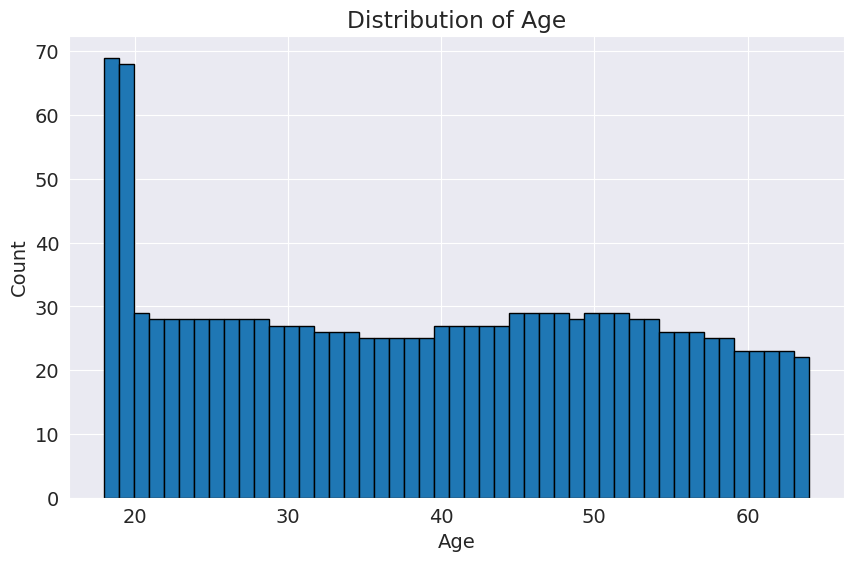

In [13]:
plt.hist(
    medical_df.age,
    bins=47,
    edgecolor='black'
)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

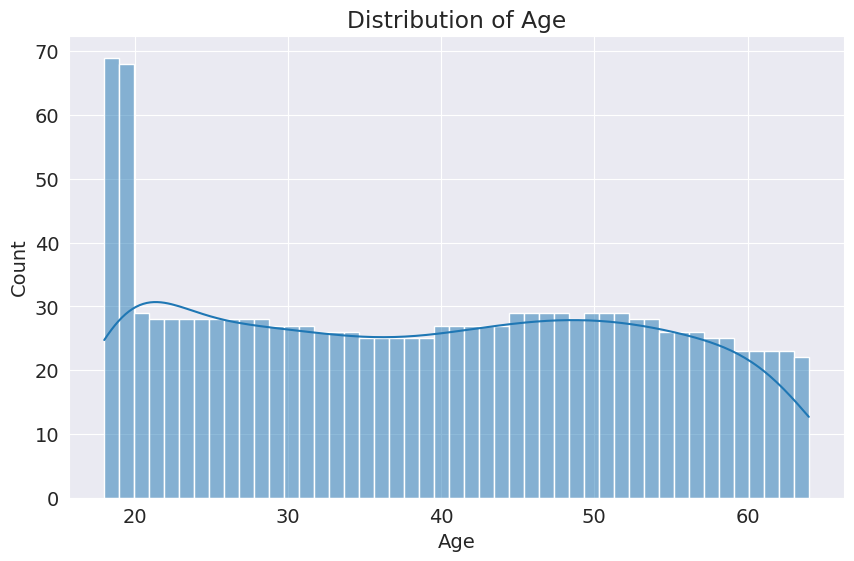

In [14]:
sns.histplot(
    data=medical_df,
    x='age',
    kde=True,
    bins=47
)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [15]:
fig = px.histogram(medical_df,
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

In [16]:
medical_df.bmi

,bmi
0,27.900
1,33.770
2,33.000
3,22.705
4,28.880
...,...
1333,30.970
1334,31.920
1335,36.850
1336,25.800


**Insights from the age distribution:**
- The age distribution is roughly uniform between 20 and 64 — all adult age groups are equally represented.
- Ages 18 and 19 appear with notably higher frequency, likely because 18/19-year-olds are the youngest adults eligible for independent insurance and enter the dataset in larger numbers as they age out of parental coverage.
- The mean age is ~39 years and the spread (std ≈ 14) confirms a wide range across the dataset.

### 2. BMI
Distribution of BMI using histogram

In [17]:
fig = px.histogram(
    data_frame=medical_df.bmi,
    x = 'bmi',
    marginal='box',
    color_discrete_sequence=['red'],
    title='Distribution of BMI (Body Mass Index)',
    nbins=45
)
fig.update_layout(
    bargap=0.1
)
fig.show()

**Insights from the BMI distribution:**
- BMI follows an approximately normal (Gaussian) distribution centred around a mean of ~30.7, which sits on the threshold of the 'obese' classification (BMI ≥ 30).
- The distribution is slightly right-skewed, meaning there are more individuals with higher BMI values than a perfect Gaussian would predict.
- Age forms a uniform distribution because the dataset was designed to sample evenly across age groups, whereas BMI is a biological measurement that naturally clusters around a population mean.

### 3. Charge

In [18]:
medical_df.charges

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


**Annual medical charges distribution**

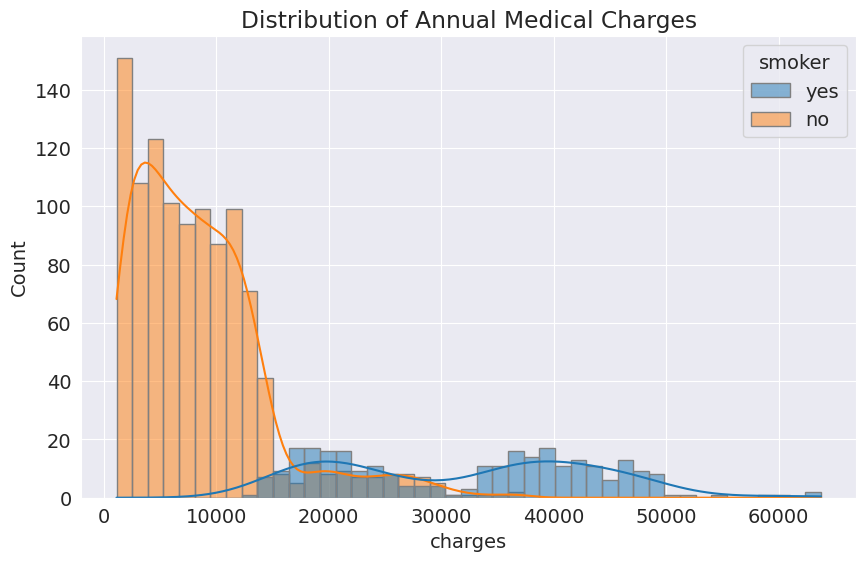

In [19]:
sns.histplot(
    data=medical_df,
    x='charges',
    hue='smoker',
    bins=45,
    color='red',
    edgecolor='grey',
    kde=True
)
plt.title('Distribution of Annual Medical Charges')
plt.show()

In [20]:
figure = px.histogram(
    data_frame=medical_df,
    x = 'charges',
    marginal='box',
    color='smoker',
    color_discrete_sequence=['green', 'grey'],
    title='Distribution of Annual Medical Charges'
)
figure.update_layout(
    bargap=0.1
)
figure.show()

**Insights from the charges distribution by smoking status:**
- The distribution is strongly right-skewed. Most patients incur relatively low charges, but a long tail extends to ~`$64k`.
- Smokers form a clearly separated higher-charge cluster concentrated in the `$15k–$50k` range, while non-smokers cluster below $15k.
- This bimodal shape confirms that smoking status is the single most dominant predictor of high medical charges.

**Note — Interactive vs. Static plots:**
Plotly Express charts are interactive: hovering over a point shows exact values. Seaborn/Matplotlib produce static images. Both are used throughout this notebook — Plotly for exploration, Seaborn for presentation-quality static figures.

Visualizing the distribution of medical charges broken down by **sex** and **region** to check whether either factor shows a meaningful separation in charge levels.

#### Sex

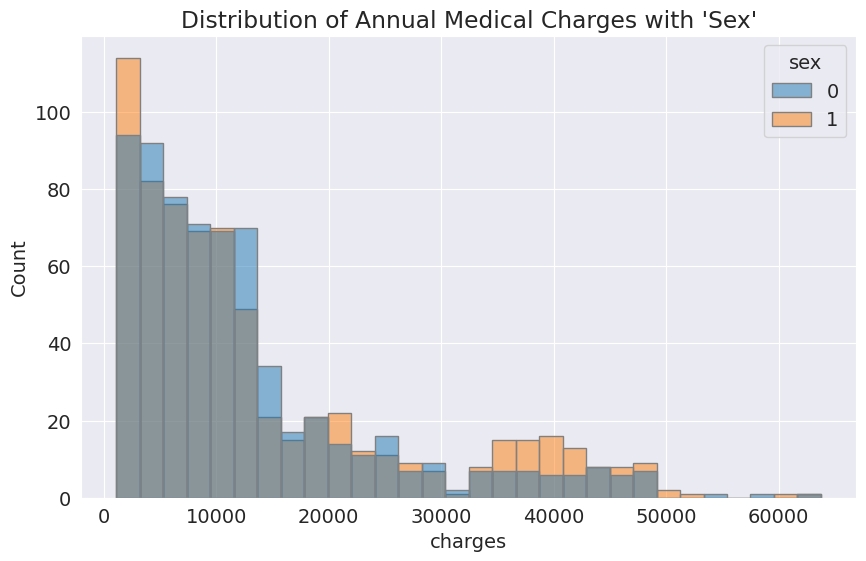

In [21]:
# sex
sns.histplot(
    data=medical_df,
    x='charges',
    hue='sex',
    color='red',
    edgecolor='grey',
    kde=False
)
plt.title('Distribution of Annual Medical Charges with \'Sex\'')
plt.show()

#### Region

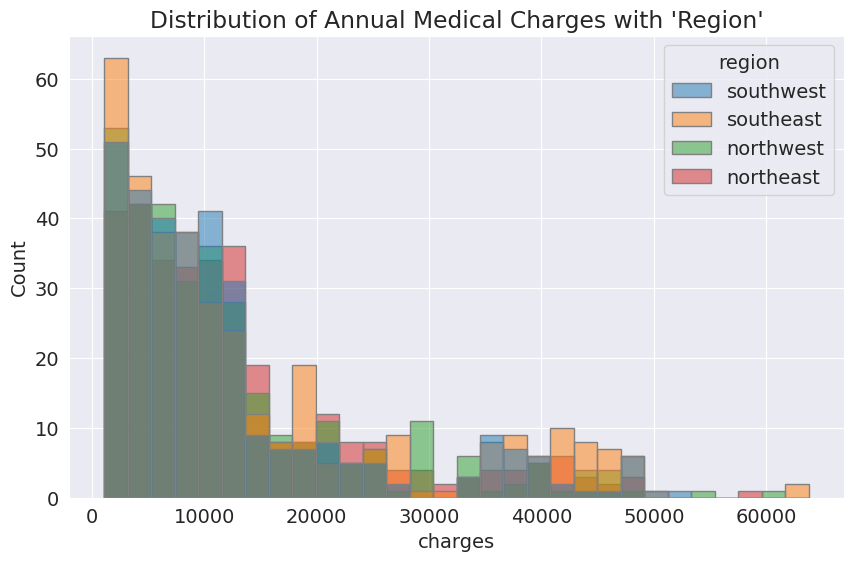

In [22]:
# region
sns.histplot(
    data=medical_df,
    x='charges',
    hue='region',
    color='red',
    edgecolor='grey',
    kde=False
)
plt.title('Distribution of Annual Medical Charges with \'Region\'')
plt.show()

### 4. Smoker

In [23]:
df = medical_df.groupby('smoker')
df.count()
# no = 1064
# yes = 274

,age,sex,bmi,children,region,charges
smoker,,,,,,
no,1064,1064,1064,1064,1064,1064
yes,274,274,274,274,274,274


In [24]:
medical_df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


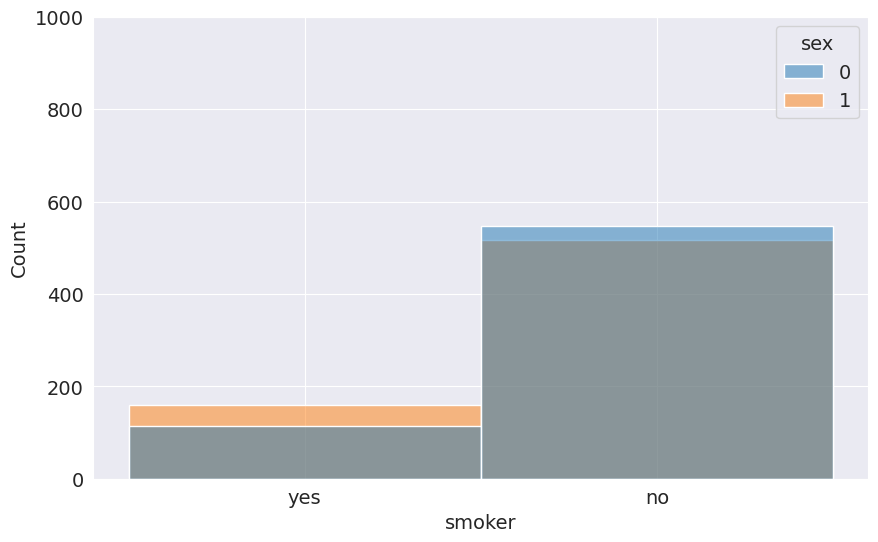

In [25]:

sns.histplot(
    data=medical_df,
    x='smoker',
    hue='sex',
    color='red'
)
plt.ylim(0, 1000)
plt.show()

In [26]:
px.histogram(
    data_frame=medical_df,
    x='smoker',
    color='sex',
    title='Smoker'
)

### 4. Sex distribution

In [27]:
medical_df['sex'].value_counts()

,count
sex,
1,676
0,662


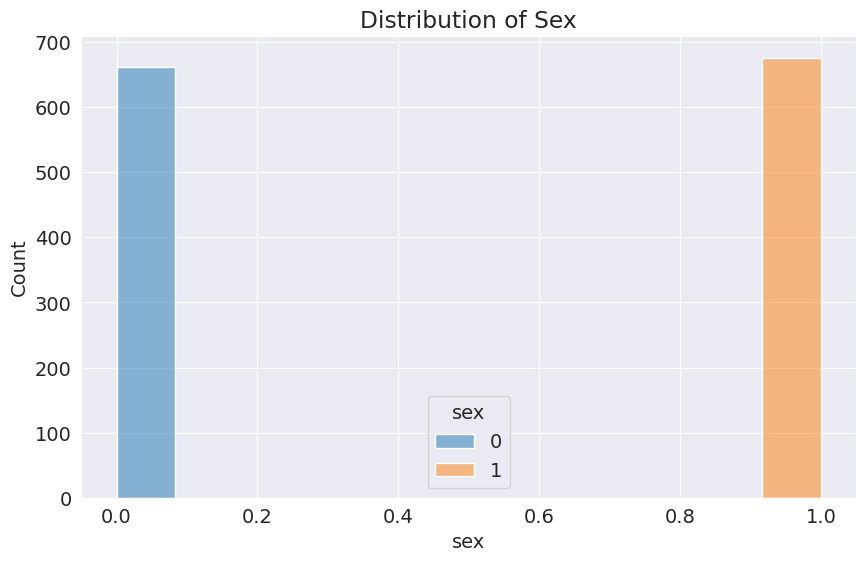

In [28]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# how can I have different colors for different categories in the same column?
sns.histplot(
    data=medical_df,
    x = 'sex',
    hue='sex'
)
plt.title('Distribution of Sex')
plt.show()

**Insights from the distribution of sex:**
- The distribution of customers by sex is relatively balanced, with a slight majority of male customers. This suggests that the insurance company has a diverse customer base in terms of gender, which could be beneficial for risk diversification and market reach. The relatively even distribution also indicates that there may not be significant gender biases in the dataset, allowing for more generalizable insights and predictions when building the linear regression model.

### 5. Region distribution

In [29]:
medical_df.region.value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


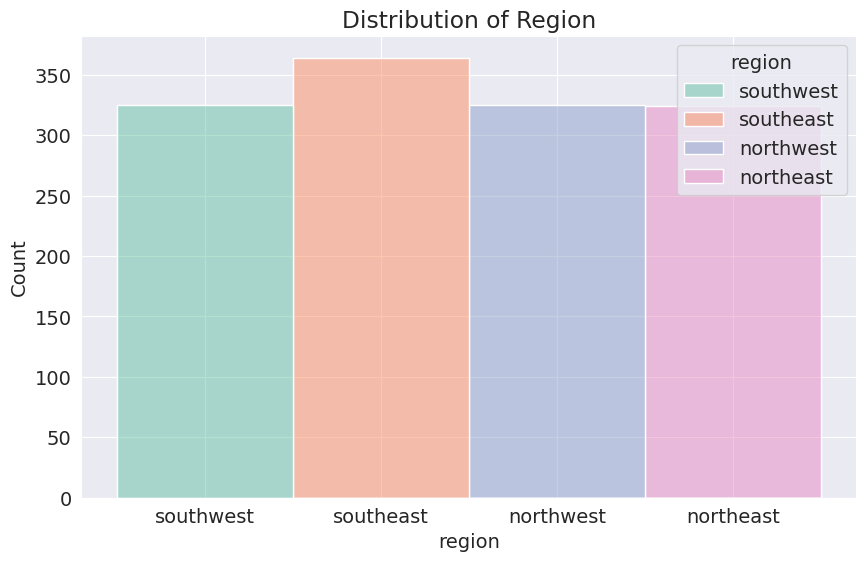

In [30]:
sns.histplot(
    data=medical_df,
    x = 'region',
    hue='region',
    palette='Set2'
)
plt.title('Distribution of Region')
plt.show()

In [31]:
px.histogram(
    data_frame=medical_df,
    x = 'region',
    color='region',
    title='Distribution of Region'
)


**Insights from the distribution of region:**
- The distribution of customers across different regions is relatively balanced, with the 'southeast' region having the highest number of customers, followed by the 'southwest', 'northeast', and 'northwest' regions. This suggests that the insurance company has a broad customer base across various geographic areas, which could be beneficial for risk diversification and market reach. The relatively even distribution also indicates that there may not be significant regional biases in the dataset, allowing for more generalizable insights and predictions when building the linear regression model.

### 6. Children distribution

In [32]:
medical_df.children.value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [33]:
px.histogram(
    data_frame=medical_df,
    x = 'children',
    color='children',
    title='Distribution of Children'
)

**Insights from the distribution of children:**
- The majority of customers have no children, which could indicate that many customers are either single or have not started a family yet.
- A significant portion of customers have 1 or 2 children which could suggest that many customers are in the early stages of family life, possibly with young children or that they have chosen to have fewer children.
- The presence of customers with 3 or more children is relatively low, which might indicate that larger families are less common among the customer base, or that they may have different insurance needs that are not as well represented in this dataset.


### 7. Age and Charges relationship

In [34]:
px.scatter(
    data_frame=medical_df,
    x = 'age',
    y = 'charges',
    color='smoker',
    hover_data='sex',
    opacity=0.7, # this parameter controls the transparency of the points in the scatter plot. A value of 0.7 means that the points will be 70% opaque and 30% transparent, allowing for better visibility of overlapping points.
    title='Relationship between Age and Charges'
)

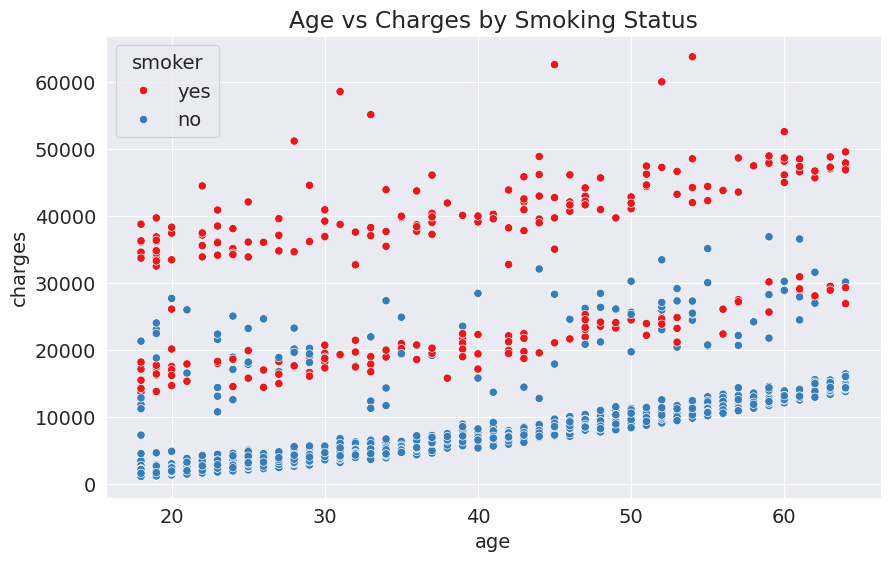

In [35]:
sns.scatterplot(
    data=medical_df,
    x='age',
    y='charges',
    hue='smoker',
    palette='Set1' # this is a color palette from seaborn that provides a set of distinct colors for categorical variables.
)
plt.title('Age vs Charges by Smoking Status')
plt.show()

**Insights from the Age vs. Charges scatter plot:**
- There is a clear positive correlation between age and charges: older patients generally incur higher costs.
- Three distinct upward-sloping bands are visible:
  - **Lower band** — non-smokers with no major health issues. Charges grow steadily but remain the lowest.
  - **Middle band** — a mix of non-smokers with health complications and lighter smokers whose bands overlap.
  - **Upper band** — primarily heavy smokers. Their baseline charges are much higher and continue rising with age.
- Smoking is the clearest separator between bands, confirming it as the strongest individual predictor of high charges.

### BMI and Charges relationship

In [36]:
px.scatter(
    data_frame=medical_df,
    x = 'bmi',
    y = 'charges',
    color = 'smoker',
    hover_data = ['sex'],
    opacity=0.8,
    title='BMI vs Charges by Smoking status'
)

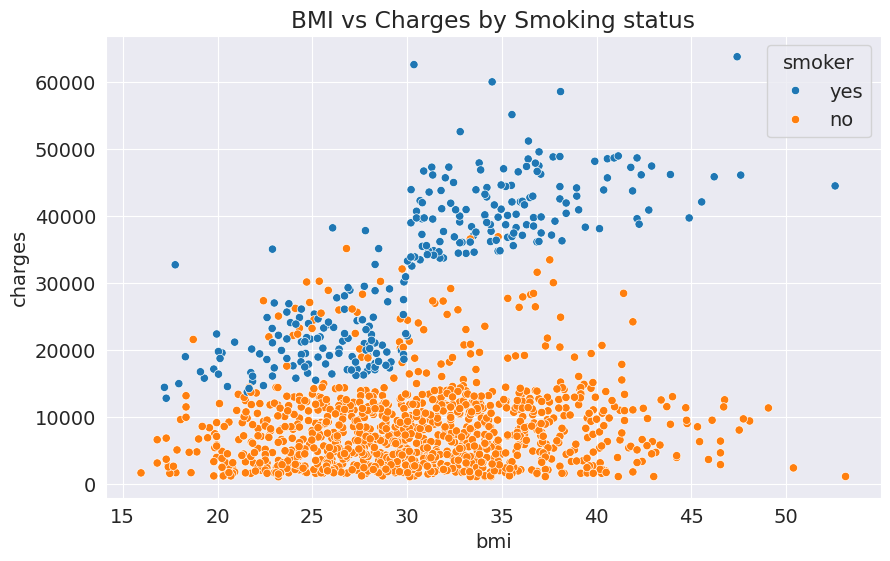

In [37]:
sns.scatterplot(
    data=medical_df,
    x = 'bmi',
    y = 'charges',
    hue = 'smoker',
)
plt.rcParams['figure.figsize'] = (20, 6)
plt.title('BMI vs Charges by Smoking status')
plt.show()

### Children and Charges relationship


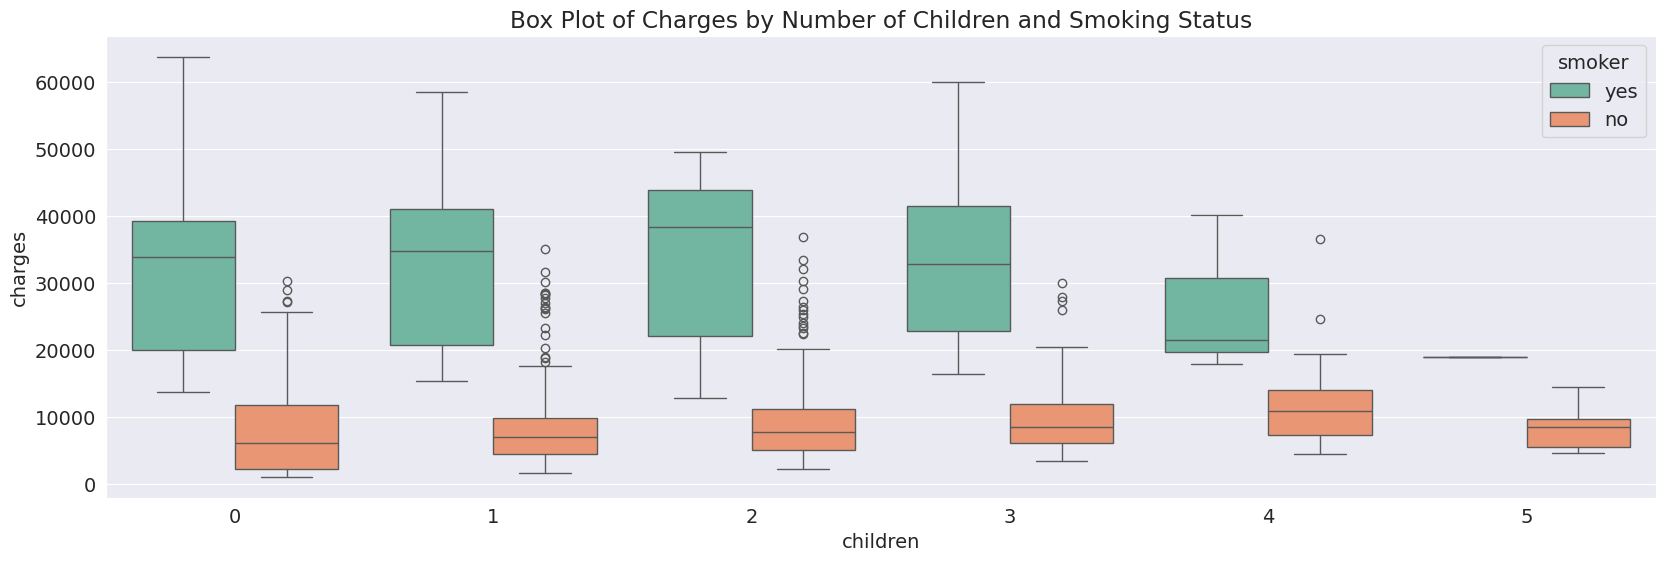

In [38]:
sns.boxplot(
    data=medical_df,
    x='children',
    y='charges',
    hue='smoker',
    palette='Set2'
)
plt.title('Box Plot of Charges by Number of Children and Smoking Status')
plt.show()

In [39]:
px.box(
    data_frame=medical_df,
    x='children',
    y='charges',
    color='smoker',
    title='Box Plot of Charges by Number of Children and Smoking Status'
)

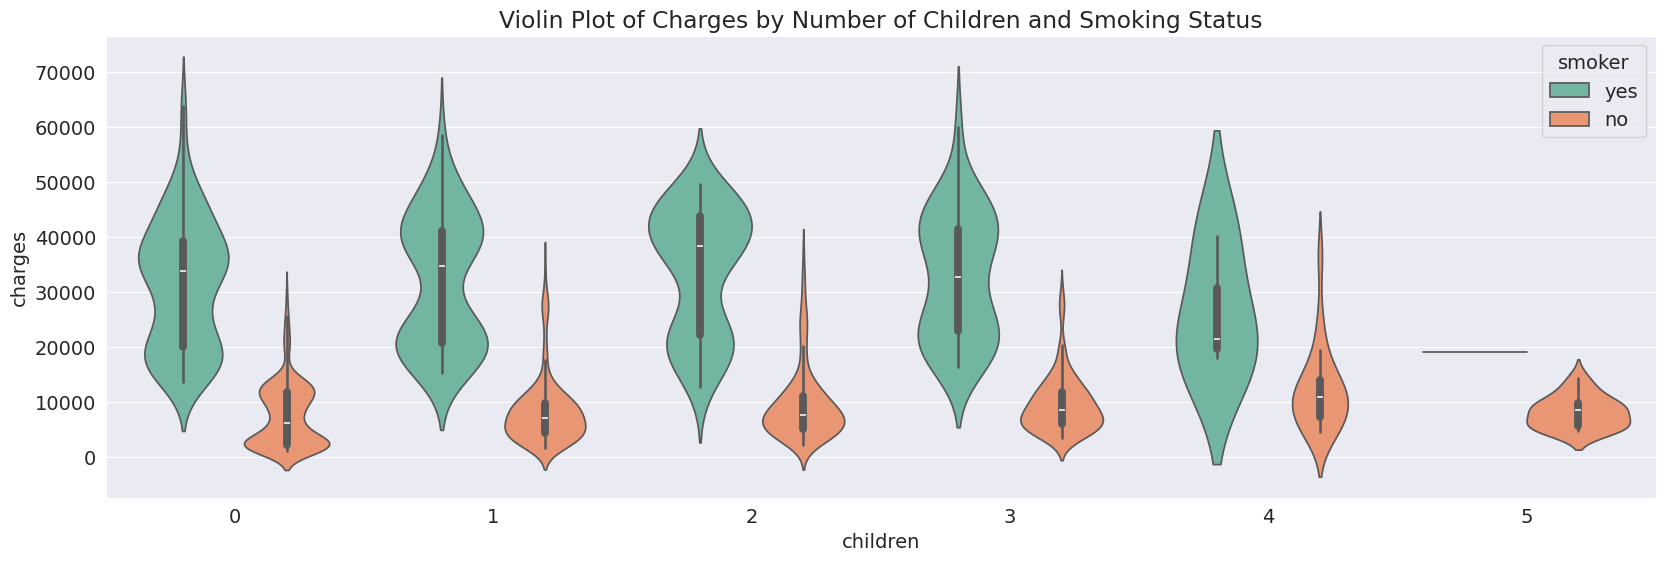

In [40]:
sns.violinplot(
    data=medical_df,
    x='children',
    y='charges',
    hue='smoker',
    palette='Set2'
)
plt.title('Violin Plot of Charges by Number of Children and Smoking Status')
plt.show()

In [41]:
fig = px.violin(
    data_frame=medical_df,
    x='children',
    y='charges',
    color='smoker',
    # box=True, # this parameter adds a box plot inside the violin plot, which shows the median and interquartile range of the data.
    # points=False, # this parameter adds all the individual data points to the violin plot, which can help to visualize the distribution of the data more clearly.
    # meanline=True, # this parameter adds a line to the violin plot that represents the mean of the data.
    title='Violin Plot of Charges by Number of Children and Smoking Status'
)
fig.update_traces(bandwidth=1000) # this parameter controls the width of the violin plot. A smaller value will make the plot narrower, while a larger value will make it wider.
fig.show()

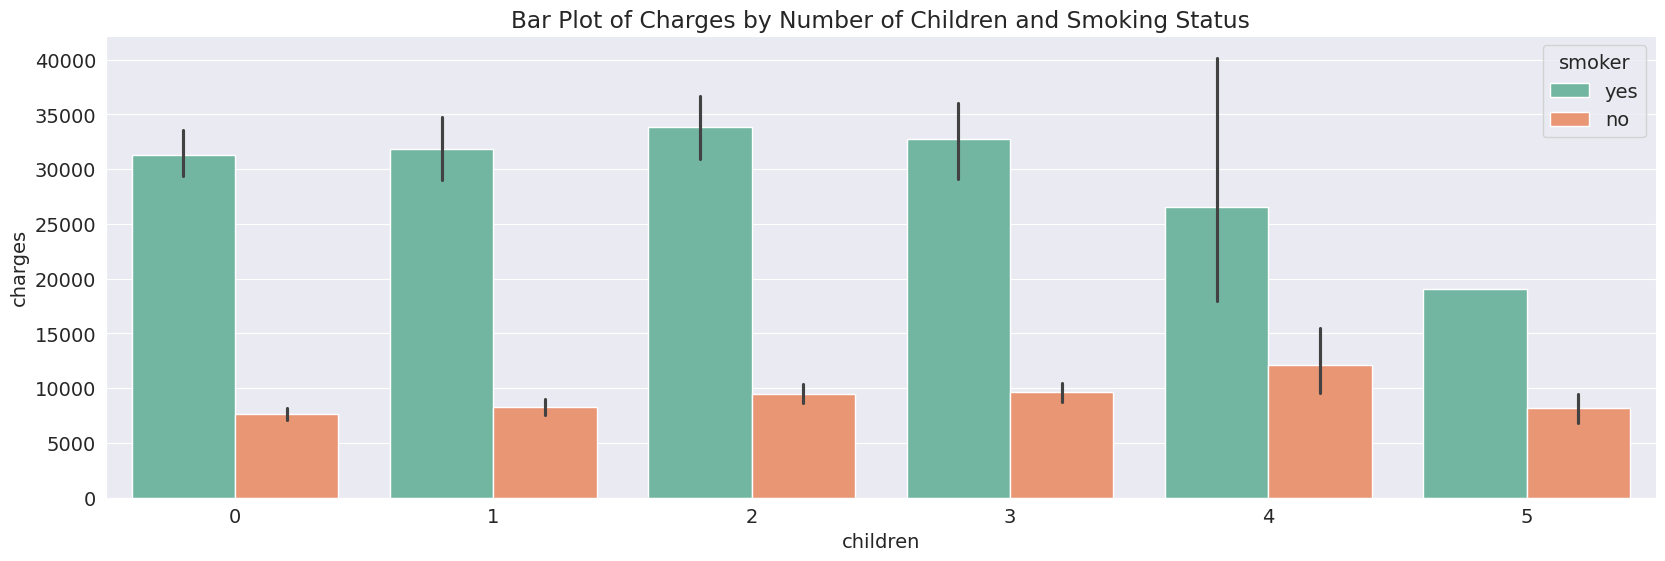

In [42]:
sns.barplot(
    data=medical_df,
    x='children',
    y='charges',
    hue='smoker',
    palette='Set2'
)
plt.title('Bar Plot of Charges by Number of Children and Smoking Status')
plt.show()

In [43]:
px.bar(
    data_frame=medical_df,
    x='children',
    y='charges',
    color='smoker',
    title='Bar Plot of Charges by Number of Children and Smoking Status'
)

### Correlation between numerical features

**First, form a correlation matrix**

In [44]:
# this is the correlation between age and charges
corr_matrix = medical_df.charges.corr(
    method='pearson', # other method options are 'spearman', 'kendall',
    other=medical_df.age
)
print(corr_matrix)

0.2990081933306476


In [45]:
# correlation between bmi and charges
corr_matrix = medical_df.charges.corr(medical_df.bmi)
print(corr_matrix)

0.19834096883362895


In [46]:
corr_matrix = medical_df.corr(numeric_only=True)
print(corr_matrix)

               age       sex       bmi  children   charges
age       1.000000 -0.020856  0.109272  0.042469  0.299008
sex      -0.020856  1.000000  0.046371  0.017163  0.057292
bmi       0.109272  0.046371  1.000000  0.012759  0.198341
children  0.042469  0.017163  0.012759  1.000000  0.067998
charges   0.299008  0.057292  0.198341  0.067998  1.000000


**Then visualize the correlation matrix using a heatmap**

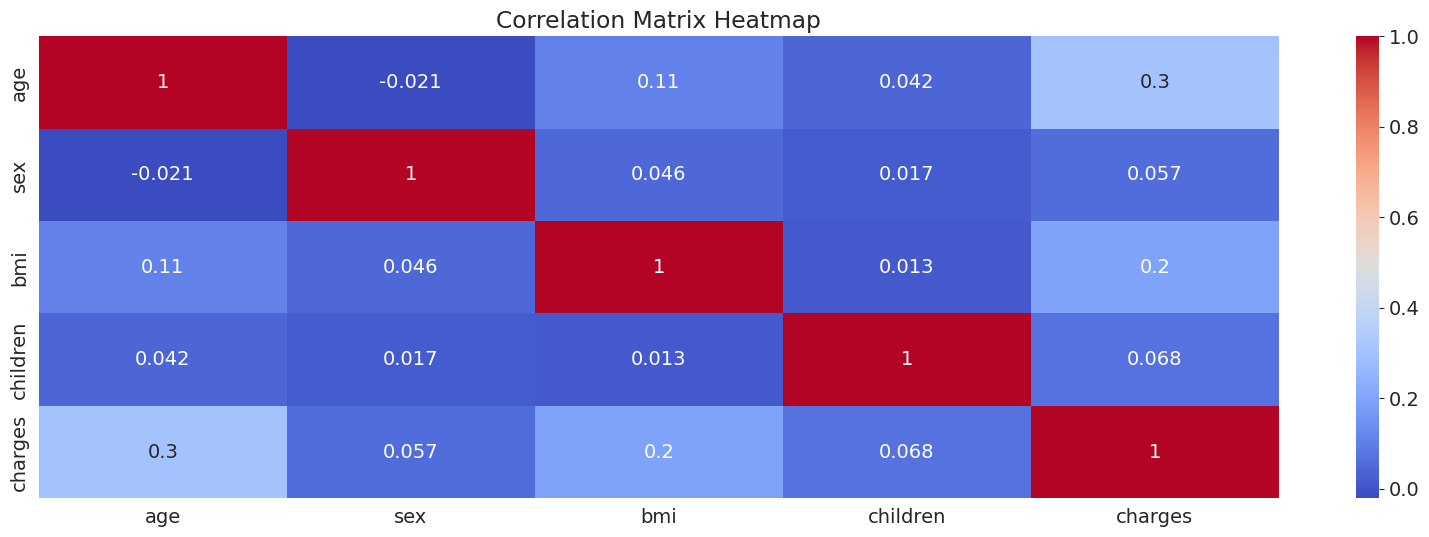

In [47]:
sns.heatmap(
    corr_matrix,
    annot=True, # this parameter adds the correlation coefficients to the heatmap, making it easier to interpret the strength and direction of the relationships between variables.
    cmap='coolwarm', # this parameter specifies the color map to use for the heatmap. 'coolwarm' is a diverging color map that ranges from cool colors (blue) for negative correlations to warm colors (red) for positive correlations, with white representing no correlation.
)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [48]:
# in plotly
px.imshow(
    corr_matrix,
    labels=dict(color='Correlation Coefficient'),
    title='Correlation Matrix Heatmap',
    aspect='auto'
)

**How to interpret the correlation coefficient:**
- **Strength** — the greater the absolute value, the stronger the relationship:
  - |r| close to 1 → strong relationship
  - |r| close to 0 → weak or no linear relationship
- **Direction**:
  - Positive r → both variables increase together
  - Negative r → one variable increases as the other decreases
- **Key observations**: `charges` correlates most strongly with `age` (r ≈ 0.30) and `bmi` (r ≈ 0.20). All other features show weak linear correlations with charges.

> **Note — Correlation vs. Causation**
>
> A high correlation between two variables does not mean one *causes* the other. For example, age and charges are correlated, but age alone does not *cause* high bills — the health conditions that accumulate with age do. Always treat correlations as associations, not causal relationships, unless supported by domain knowledge or controlled experiments.

## Linear Regression using a Single Feature

Let's try to find a way of estimating the value of "charges" using the value of "age" for non-smokers. First, let's create a data frame containing just the data for non-smokers.

In [49]:
non_smokers_df = medical_df[medical_df['smoker'] == 'no']
non_smokers_df

,age,sex,bmi,children,smoker,region,charges
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520
5,31,0,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,0,44.700,3,no,southwest,11411.68500
1333,50,1,30.970,3,no,northwest,10600.54830
1334,18,0,31.920,0,no,northeast,2205.98080
1335,18,0,36.850,0,no,southeast,1629.83350


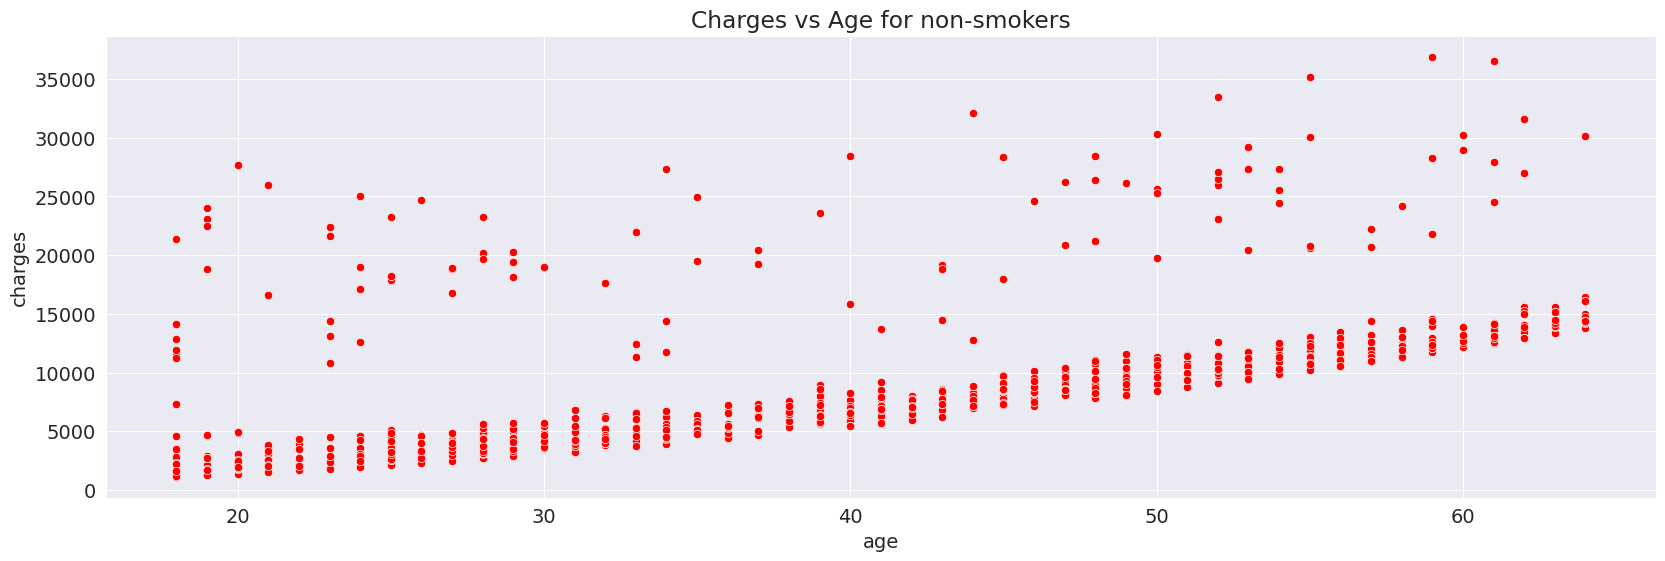

In [50]:
# charge vs age
sns.scatterplot(
    data=non_smokers_df,
    x = 'age',
    y = 'charges',
    color = 'red',
    # alpha = 0.5,
    # s = 15
)
plt.title('Charges vs Age for non-smokers')
plt.show()

In [51]:
px.scatter(
    data_frame=non_smokers_df,
    x = 'age',
    y = 'charges',
    title='Charges vs Age for non-smokers'
)

Let define a helper function `estimate_charges`, to compute charges given `age`, `w` and `b`.

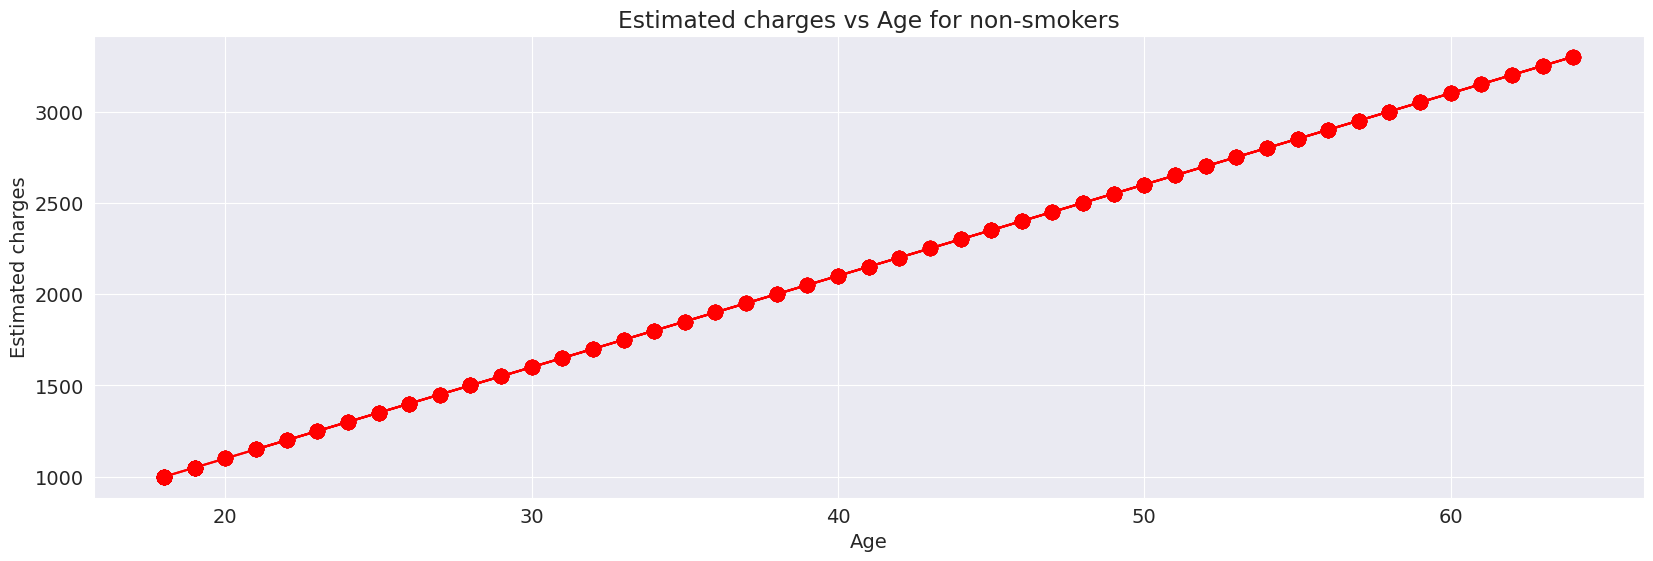

In [52]:
# charges = w * charges + b
def estimate_charges(age, w, b):
    return age * w + b
w = 50
b = 100
age =  non_smokers_df.age
estimated_charges = estimate_charges(age=age, w=w, b=b)
plt.plot(age, estimated_charges, 'r-o')
plt.plot(
    age,
    estimated_charges,
    marker='o',
    linestyle='solid',
    color='red',
    # markeredgecolor='red',
    # markerfacecolor='red',
    markersize=10
)
plt.title('Estimated charges vs Age for non-smokers')
plt.xlabel('Age')
plt.ylabel('Estimated charges')
plt.show()

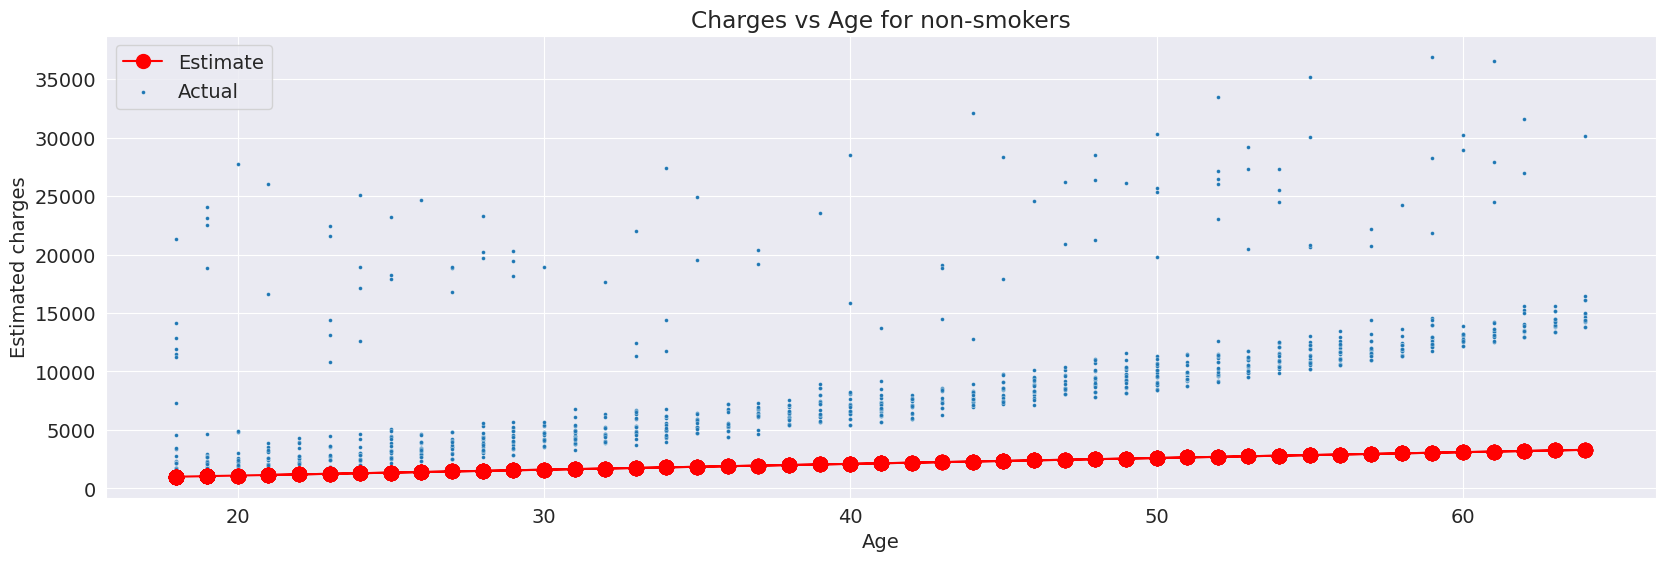

In [53]:
plt.plot(
    age,
    estimated_charges,
    marker='o',
    linestyle='solid',
    color='red',
    # markeredgecolor='red',
    # markerfacecolor='red',
    markersize=10
)
sns.scatterplot(
    data=non_smokers_df,
    x = 'age',
    y = 'charges',
    # color = 'red',
    # alpha = 0.5,
    s = 8
)
plt.title('Charges vs Age for non-smokers')
plt.xlabel('Age')
plt.legend(['Estimate', 'Actual'])
plt.ylabel('Estimated charges')
plt.show()

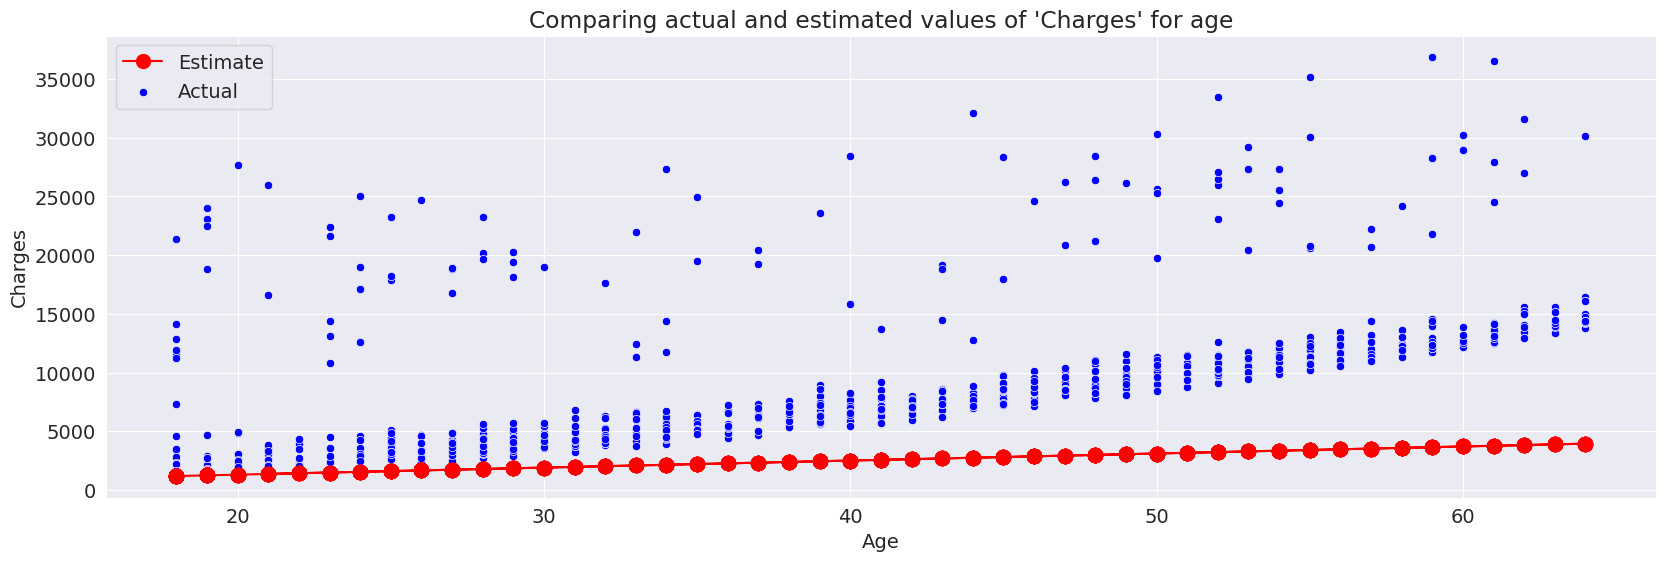

In [54]:
def try_parameters(w, b):
    age = non_smokers_df.age
    target = non_smokers_df.charges
    estimated_charges = estimate_charges(age, w, b)
    plt.plot(age, estimated_charges, marker='o', linestyle='-', color='red', ms=10)

    sns.scatterplot(x = age, y = target, color='blue')

    plt.title('Comparing actual and estimated values of \'Charges\' for age')
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])
    plt.show()

try_parameters(60, 100) # w, b

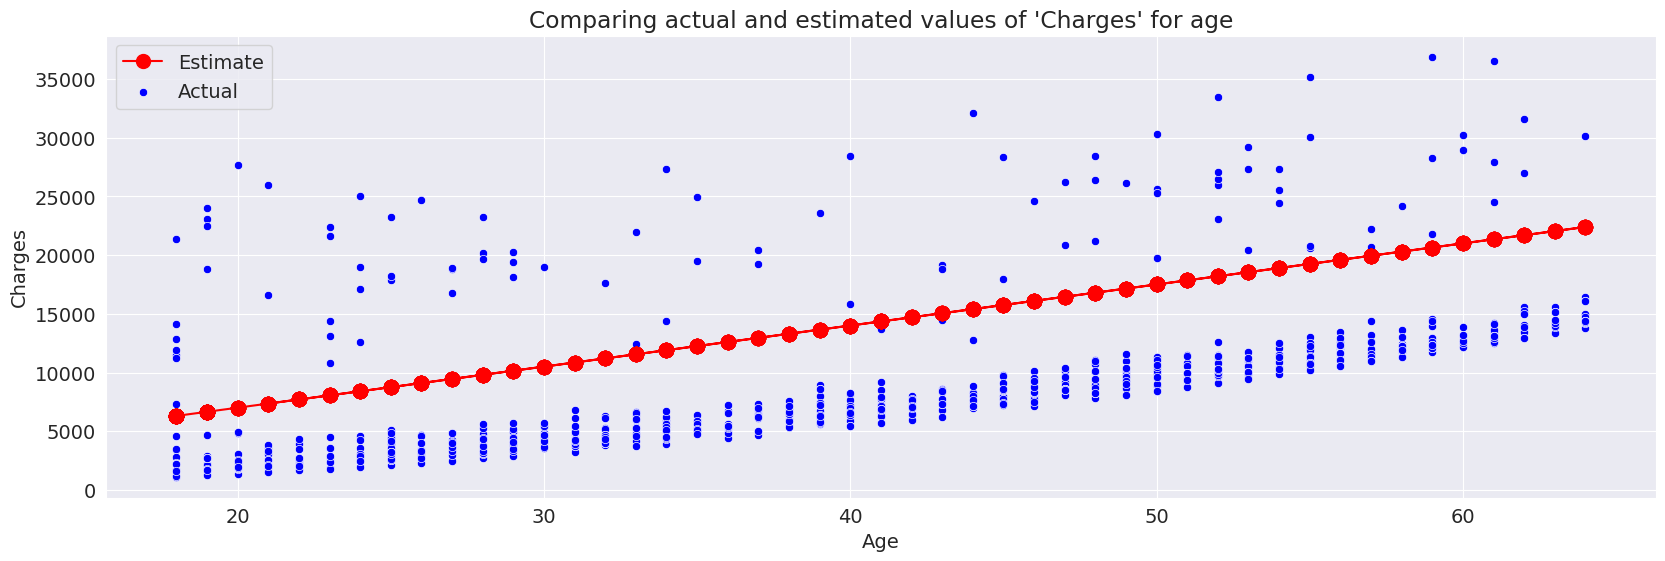

In [55]:
try_parameters(350, 4) # w, b

**Effect of `w` and `b` on the regression line:**
- **`w` (slope)** controls steepness. A larger positive `w` means charges grow faster with age; a negative `w` would mean charges decrease with age.
- **`b` (intercept)** shifts the entire line up or down without changing its slope. It represents the estimated charges when age is zero.
- Together they fully define the line: `charges = w × age + b`.

Trying parameters manually is tedious. Linear regression solves this automatically by finding the values of `w` and `b` that minimise the loss across the entire dataset. This requires:
1. A **loss function** — a numeric measure of how far predictions are from actual targets (RMSE is used here).
2. An **optimisation algorithm** — a method for efficiently finding the `w` and `b` that give the lowest loss (e.g. ordinary least squares or gradient descent).

#### Loss/Cost Function

The loss function measures how well the model is performing. For linear regression, we typically use the Mean Squared Error (MSE) as the loss function.

In [56]:
import numpy as np
# sqrt(average((targets - predictions)^2))
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))


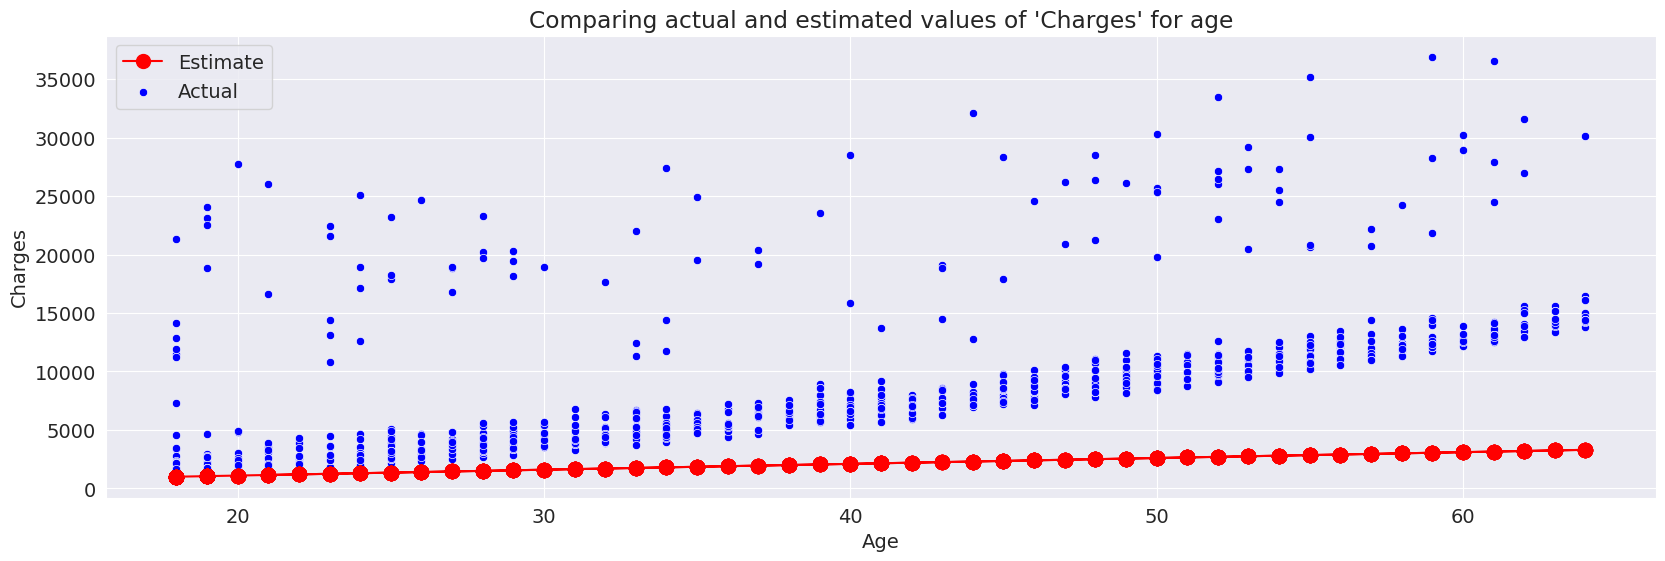

In [57]:
try_parameters(50, 100)

In [58]:
target = non_smokers_df.charges
predicted = estimate_charges(non_smokers_df.age, 50, 100)
print(rmse(target, predicted))

8461.949562575493


This 8461.949 means on average each element in prediction differs from the actual target by `$8461`. The result is called the **loss** because it indicates how bad the model is at predicting the target variables. It represents information loss in the model: the lower the loss, the better the model.

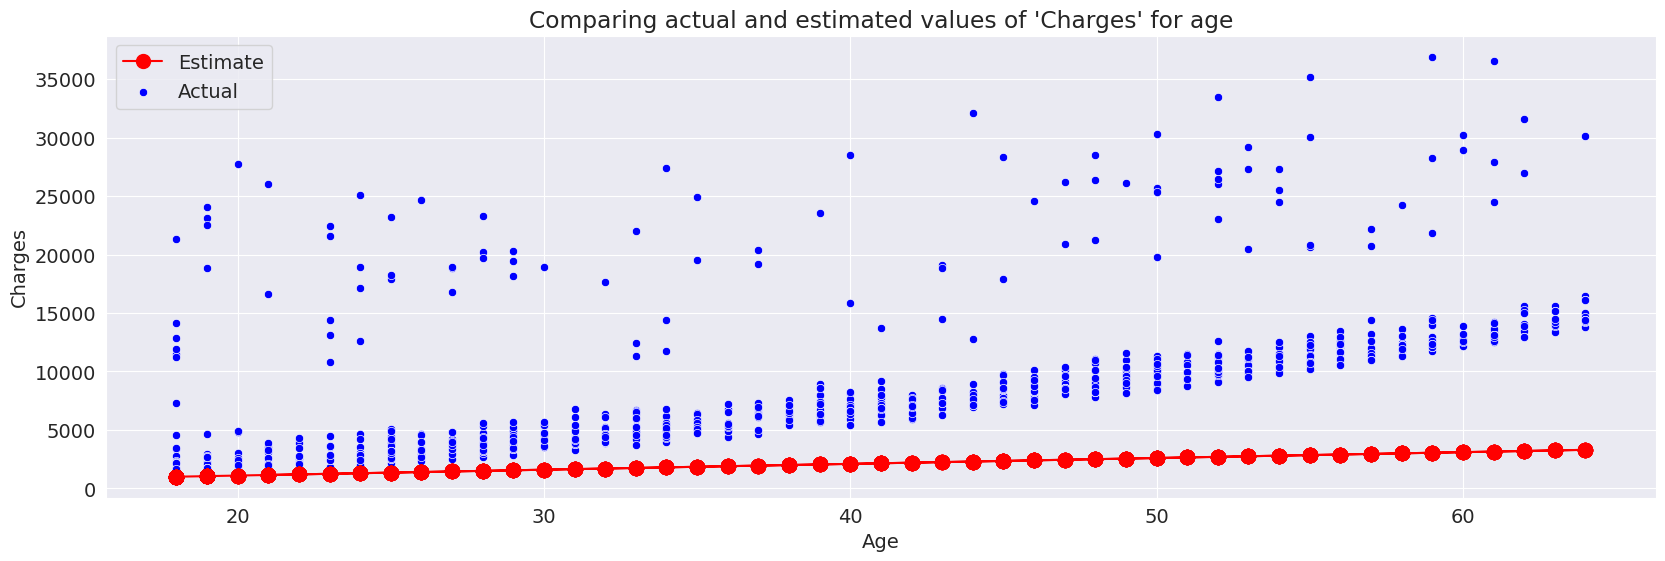

RMSE Loss: 8461.949562575493


In [59]:
def try_parameters(w, b):
    age = non_smokers_df.age
    target = non_smokers_df.charges
    estimated_charges = estimate_charges(age, w, b)
    plt.plot(age, estimated_charges, marker='o', linestyle='-', color='red', ms=10)

    sns.scatterplot(x = age, y = target, color='blue')

    plt.title('Comparing actual and estimated values of \'Charges\' for age')
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])
    plt.show()
    loss = rmse(target, estimated_charges)
    print(f'RMSE Loss: {loss}')
try_parameters(50, 100) # w, b

### Linear Regression using Scikit-learn

In [60]:
from sklearn.linear_model import LinearRegression
model = LinearRegression() # uses ordinary least square optimization technique
# help(model.fit) # with this I can also get help on how to use the model

In [61]:
inputs = non_smokers_df[
    ['age']
]
target = non_smokers_df.charges
print(inputs.shape)

(1064, 1)


In [62]:
model.fit(inputs, target)

LinearRegression()

In [63]:
prediction = model.predict(inputs)
print('RMSE:', rmse(target, prediction))

RMSE: 4662.505766636395


Parameters are stored in `coef_` and `intercept_`

In [64]:
# y = mx + b
print(model.coef_) # coef_ = slope = m
print(model.intercept_) # intercept_ = intercept = b

[267.24891283]
-2091.4205565650864


This means
$y = 267.25x - 2091.42$.\
This is what model used to predict values

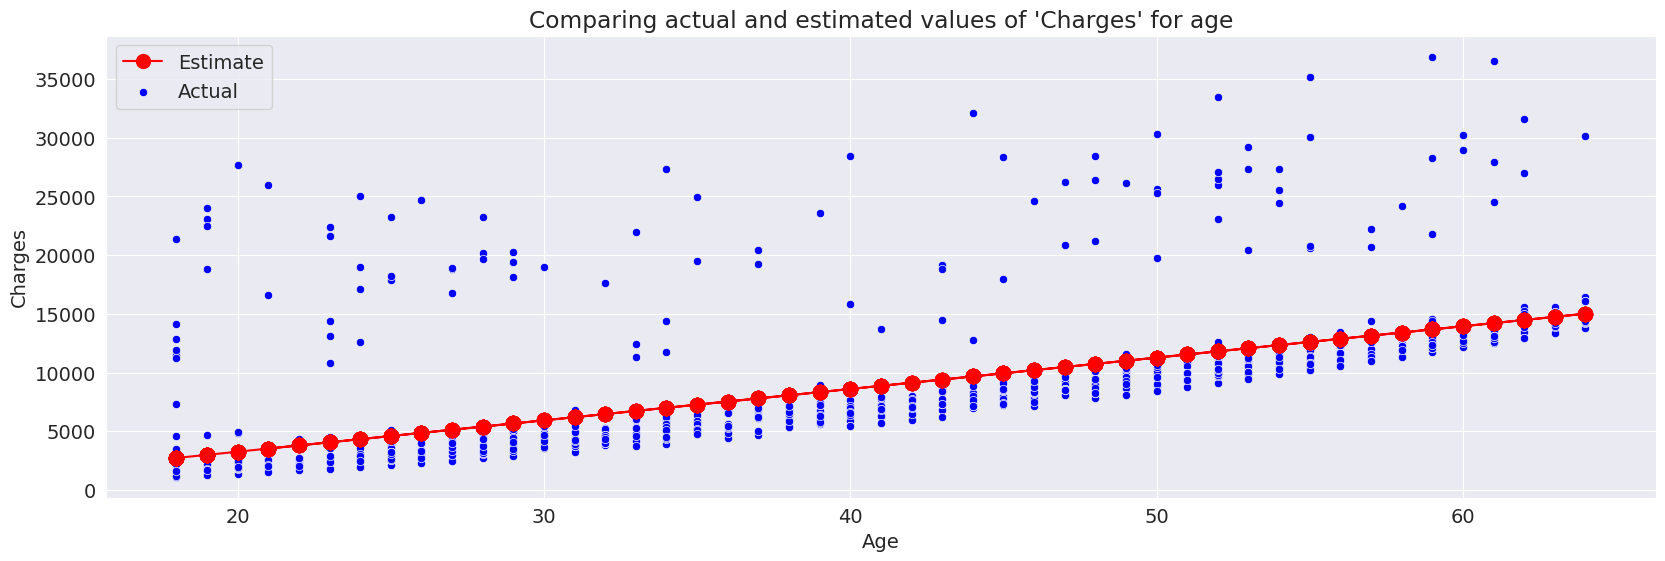

RMSE Loss: 4662.505766636395


In [65]:
try_parameters(model.coef_, model.intercept_)

The cell below trains an equivalent model using `SGDRegressor` (stochastic gradient descent). It should converge to very similar coefficients and RMSE as the `LinearRegression` model above, confirming that both optimisation methods find the same solution.

In [66]:
from sklearn.linear_model import SGDRegressor
model = SGDRegressor()
inputs = non_smokers_df[['age']]
target = non_smokers_df.charges
model.fit(inputs, target)
predicted = model.predict(inputs)

print('RMSE:', rmse(target, predicted))
print('coef_:', model.coef_)
print('intercept_:', model.intercept_)

RMSE: 5608146301.154692
coef_: [-19741344.37304544]
intercept_: [-4.8237288e+09]


Now repeating the same linear regression workflow for **smokers** — fitting a model, visualising predictions against actual charges, and computing the RMSE.

In [67]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor

smokers_df = medical_df[medical_df['smoker'] == 'yes']

model_smokers = make_pipeline(
    StandardScaler(),
    SGDRegressor(
        random_state=42,
        max_iter=5000,
        tol=1e-4,
        shuffle=True
    )
)
inputs_s = smokers_df[['age']]
target_s = smokers_df.charges

model_smokers.fit(inputs_s, target_s)
predicted_s = model_smokers.predict(inputs_s)
print('RMSE (smokers):', rmse(target_s, predicted_s))

RMSE (smokers): 10711.029450839265


## Model Evaluation

Evaluating both models using three standard regression metrics:
- **RMSE** (Root Mean Squared Error) — same unit as charges ($); penalises large errors heavily.
- **MAE** (Mean Absolute Error) — average absolute dollar difference between prediction and actual.
- **R²** (Coefficient of Determination) — proportion of variance in charges explained by the model (1.0 = perfect).

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ── Non-smokers: LinearRegression ──
model_lr = LinearRegression()
inputs_ns = non_smokers_df[['age']]
target_ns = non_smokers_df.charges
model_lr.fit(inputs_ns, target_ns)
pred_ns = model_lr.predict(inputs_ns)

rmse_ns  = np.sqrt(mean_squared_error(target_ns, pred_ns))
mae_ns   = mean_absolute_error(target_ns, pred_ns)
r2_ns    = r2_score(target_ns, pred_ns)

# ── Smokers: SGDRegressor (pipeline) ──
pred_s   = model_smokers.predict(inputs_s)
rmse_s   = np.sqrt(mean_squared_error(target_s, pred_s))
mae_s    = mean_absolute_error(target_s, pred_s)
r2_s     = r2_score(target_s, pred_s)

print(f'{'Metric':<8}  {'Non-smokers (LR)':>20}  {'Smokers (SGD)':>15}')
print('-' * 48)
print(f'{'RMSE':<8}  {rmse_ns:>20.2f}  {rmse_s:>15.2f}')
print(f'{'MAE':<8}  {mae_ns:>20.2f}  {mae_s:>15.2f}')
print(f'{'R²':<8}  {r2_ns:>20.4f}  {r2_s:>15.4f}')

Metric        Non-smokers (LR)    Smokers (SGD)
------------------------------------------------
RMSE                   4662.51         10711.03
MAE                    2580.52         10096.23
R²                      0.3943           0.1356


**Interpreting the results:**
- A low R² on both groups (typically 0.3–0.5 when using only `age`) indicates that age alone explains a limited share of the variance in charges. Adding more features (BMI, region, children) would improve the score.
- The RMSE for smokers is expected to be higher because smokers’ charges are more spread out and harder to predict with a single feature.
- MAE gives a more interpretable ‘average error in dollars’ compared to RMSE, which amplifies the impact of large outliers.